In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass
#jax.config.update("jax_disable_jit", True)

import pickle

In [2]:
import nambu_class as nmb
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt
import Usadel_methods as usadel


#jax.config.update("jax_disable_jit", True)


In [3]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000
# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
sigma_scatterings = {'Phonon': 0.1} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

print(my_usadel._get_BCS_coupling())
print(my_usadel.eta)

0.24423933
0.052916314


### Run $\Delta(Q,T)$ and $J(Q,T)$ curves

In [9]:
temp_list = jnp.linspace(0.5, 1.2, 1)
Q_list = jnp.linspace(0.0,0.7,30)

In [10]:
gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

100%|██████████| 30/30 [04:16<00:00,  8.54s/it]


[1.0194782e+00 1.0182583e+00 1.0146104e+00 1.0084831e+00 9.9967992e-01
 9.8822469e-01 9.7388995e-01 9.5645159e-01 9.3561280e-01 9.1098756e-01
 8.8206828e-01 8.4818584e-01 8.0841601e-01 7.6147592e-01 7.0546979e-01
 6.3741773e-01 5.5170709e-01 4.3733674e-01 2.5568447e-01 1.1918618e-05
 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05
 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05]


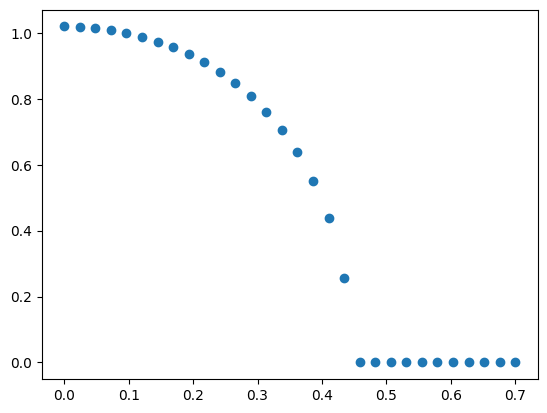

[ 0.0000000e+00  3.6683369e-01  7.2859204e-01  1.0801491e+00
  1.4159929e+00  1.7309123e+00  2.0190556e+00  2.2743301e+00
  2.4901850e+00  2.6595218e+00  2.7745543e+00  2.8267066e+00
  2.8063164e+00  2.7025940e+00  2.5032451e+00  2.1942687e+00
  1.7576898e+00  1.1763749e+00  4.2683154e-01 -2.6006232e-05
 -2.7374981e-05 -2.8743731e-05 -3.0112478e-05 -3.1481228e-05
 -3.2849977e-05 -3.4218727e-05 -3.5587473e-05 -3.6956226e-05
 -3.8324975e-05 -3.9693721e-05]


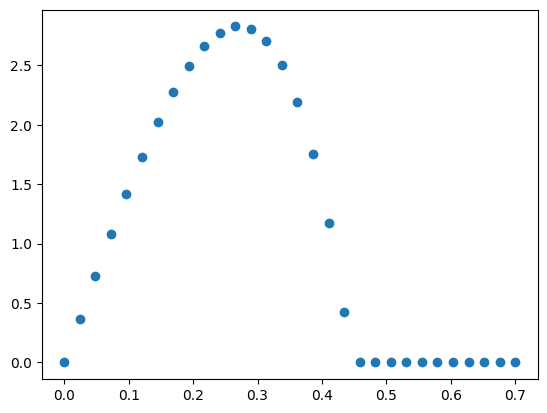

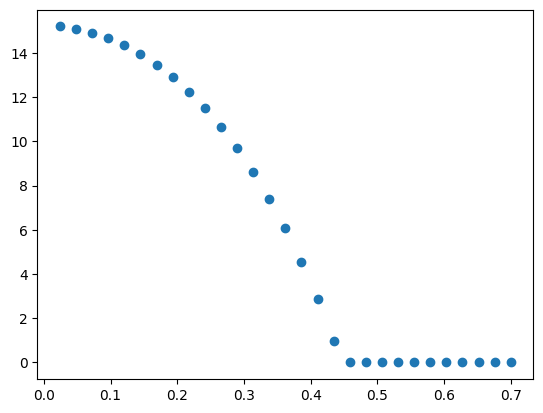

In [11]:
#print(gap_list)
#plt.scatter(temp_list,gap_list)
plt.scatter(Q_list,gap_list.T)
print(gap_list[0])
plt.show()
print(current_list[0])
plt.scatter(Q_list,current_list[0].real)
plt.show()
plt.scatter(Q_list,current_list[0].real/Q_list)
#plt.plot(Q_list,np.abs(gap_list.T[0])* (1 - Q_list**2/gap_list.T[0]/2) ** (3/2), 'k--')

In [ ]:
x

### Run $Q(t)$ pulse simulation for weak pulses 

In [ ]:
current_function = lambda x: jnp.exp(-x**2) * 0.1
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(0.3, current_function=current_function, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)

In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

plt.plot(times, jnp.gradient(q_vs_time,times))

plt.show()

plt.plot(times, jnp.gradient(q_vs_time,times)* 10 + current_vs_time)
plt.plot(times, pulse_in)

## Run procedure for actual data

In [39]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 500}
sigma_scatterings = {'Phonon': 0.2} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)
print('eta/T_c is', my_usadel.eta)
print('Cutoff is', my_usadel.cutoff)
#TODO: run vs T for different Q values, T-Q plane



eta/T_c is 0.052916314
Cutoff is 52.916313


### Find current scaling factor

In [40]:
Q_list = jnp.sort(jnp.append(jnp.linspace(0.0,0.7,10),jnp.linspace(0.25,0.45,10)))

In [41]:
gap_list, current_list = comp.calculate_equilibrium([run_temperature], grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

100%|██████████| 20/20 [02:50<00:00,  8.51s/it]


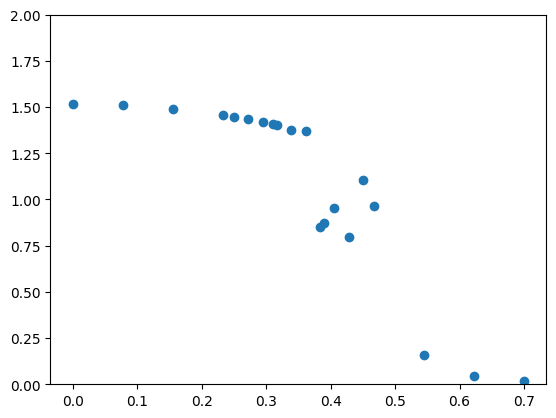

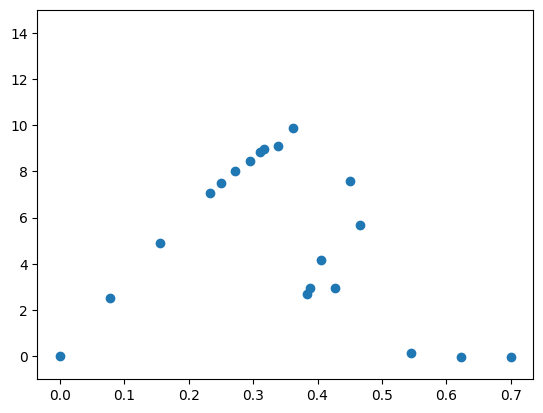

1.5174296


In [43]:
plt.scatter(Q_list,gap_list.T)
plt.ylim(0,2)
plt.show()
plt.scatter(Q_list,current_list[0].real)
plt.ylim(-1,15) 
plt.show()
print(jnp.max(gap_list.T[:3]))

In [11]:
CURRENT_MAXIMUM = jnp.max(current_list[0])
print(CURRENT_MAXIMUM)


9.268737


In [ ]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 500}
sigma_scatterings = {'Phonon': 0.3} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5


my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)
print('eta/T_c is', my_usadel.eta)
print('Cutoff is', my_usadel.cutoff)
#TODO: run vs T for different Q values, T-Q plane



### Define the current relative to that scaling factor

In [ ]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'z_t/R_n': 50/130}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
#sigma_scatterings = {'Elastic': 10.0, 'Dynes': 5.0} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

run_temperature = 0.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

In [ ]:
Q_list = jnp.linspace(0.0,0.7,30)

In [ ]:
gap_list, current_list = comp.calculate_equilibrium([run_temperature], grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None,  Q_list = Q_list)

In [ ]:
plt.plot(Q_list,gap_list.T)
plt.show()
plt.plot(Q_list,current_list[0].real)
plt.show()

### Run Individual Q(t) scans

In [ ]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)

In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

In [ ]:
crt_pulse = lambda x: 1.0 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)


In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

In [ ]:
crt_pulse = lambda x: 3.0 * current_function_gaussian(x)

times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)


In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

#TODO: kick it with a random seed on top of last solution

print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

## Test Normal state resistivity

In [12]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.1} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 1.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [14]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 99/99 [06:48<00:00,  4.13s/it]


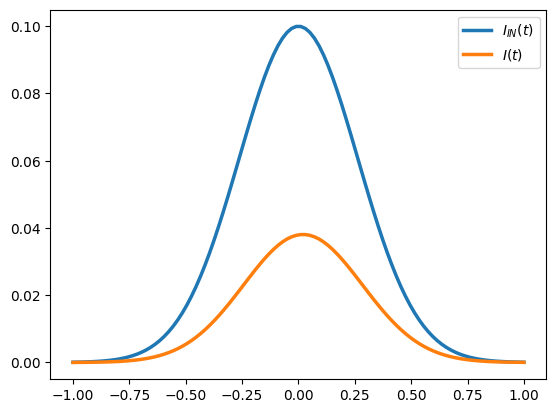

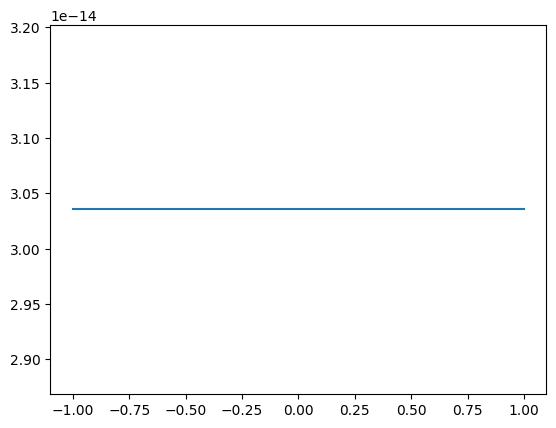

Transmitivity is 0.38066158


In [15]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

## Testing superfluid response with normal fluid (low T)

In [12]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.3} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [13]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 99/99 [07:34<00:00,  4.59s/it]


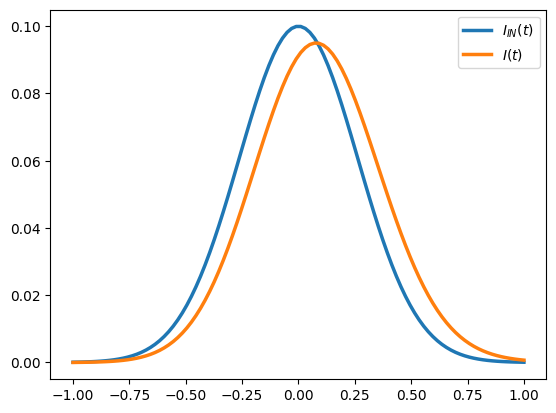

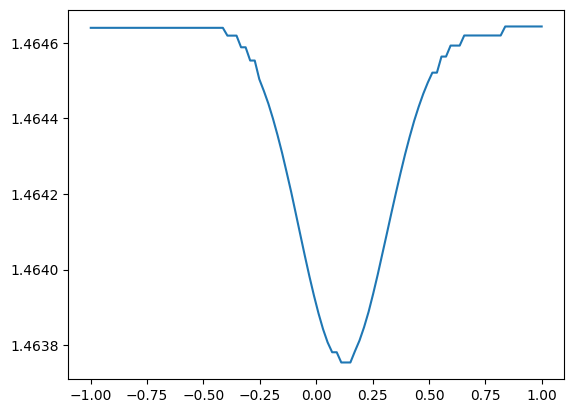

Transmitivity is 0.9506345


In [14]:
#* Without normal fluid response it looks like this

plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

## Run the full parameter scan for T = 0.5T_c

In [23]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 9.268737, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.3} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [24]:
current_amplitudes = np.linspace(0.1, 6, 10)
times_out = []
pulse_in_out = []
current_vs_time_out = []
gap_vs_time_out = []
q_vs_time_out = []
transmitivity_out = []
current_inside_out = []

for amp in current_amplitudes:
    crt_pulse = lambda x: amp * current_function_gaussian(x)
    times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
    times_out += [times]
    pulse_in_out += [pulse_in]
    current_vs_time_out += [current_vs_time]
    gap_vs_time_out += [gap_vs_time]
    q_vs_time_out += [q_vs_time]
    transmitivity_out += [jnp.max(current_vs_time)/jnp.max(pulse_in)]
    current_inside_out += [jnp.max(current_vs_time)]

100%|██████████| 99/99 [05:08<00:00,  3.12s/it]


In [25]:
def save_data(data, filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data, output)
        
def load_data(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data


def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

    return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]


In [26]:
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')


(99, 4)


In [27]:
normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3


(99, 4)


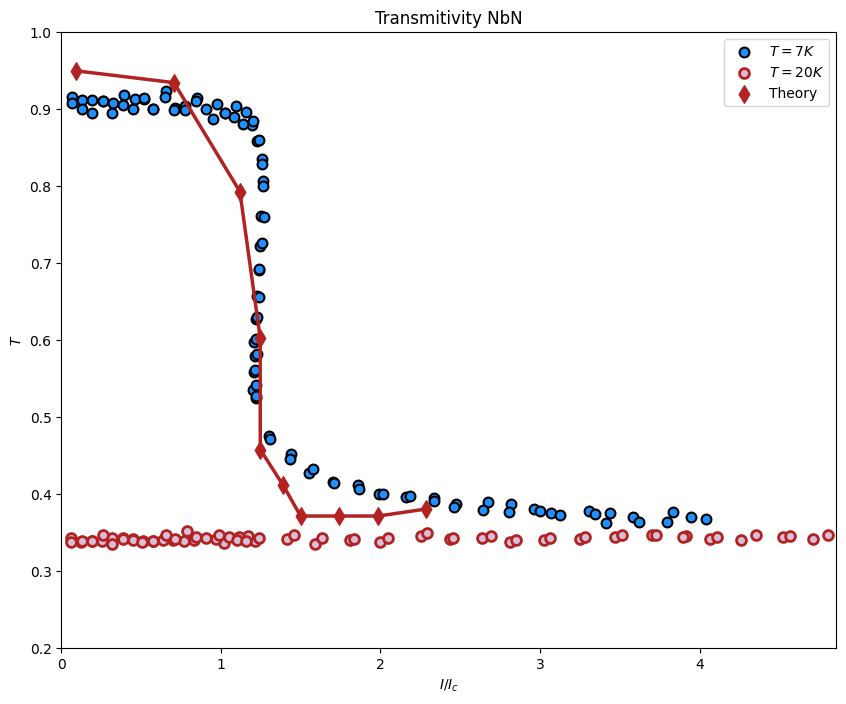

In [28]:
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

I_c = 35
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,170/I_c)



plt.scatter(current_inside_out, np.array(current_inside_out)/current_amplitudes, marker = 'd', color = 'firebrick', s = 80, label = r'Theory')
plt.plot(current_inside_out, np.array(current_inside_out)/current_amplitudes, color = 'firebrick', linewidth = 2.5)
plt.xlabel(r'$I/I_c$')
plt.ylabel(r'$T$')
plt.legend()

plt.savefig('Dirty supercondutor - medium eta - medium phonons.png', dpi = 300)

(99, 4)


/tmp/ipykernel_26499/862381141.py:15: RuntimeWarning: invalid value encountered in divide
  axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)


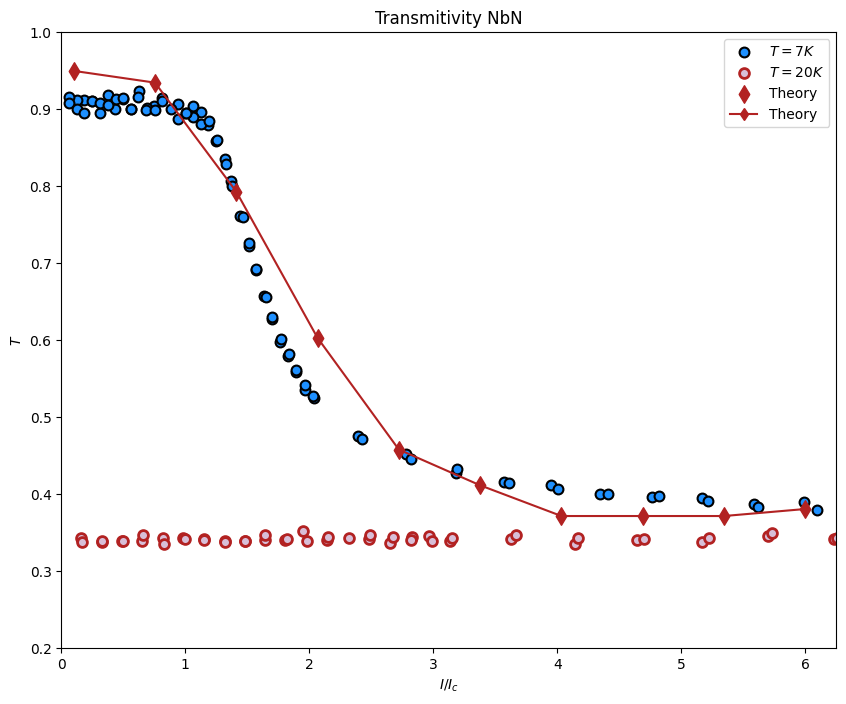

In [31]:
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

I_c = 40
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c/sc_data_y, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)


plt.scatter(current_amplitudes, np.array(current_inside_out)/current_amplitudes, marker = 'd', color = 'firebrick', s = 80, label = r'Theory')
plt.plot(current_amplitudes, np.array(current_inside_out)/current_amplitudes, marker = 'd', color = 'firebrick', label = r'Theory')

plt.xlabel(r'$I/I_c$')
plt.ylabel(r'$T$')
plt.legend()

#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

In [ ]:
#plot delta * dtQ/(Q) and delta_max * dtQ/Q

## Run a full procedure

In [12]:
import numpy as np 

def run_full_scan(temp, phonon_scattering, eta, filename = None ):

    if filename is None:
        filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,3)) + ' eta:' + str(np.round(eta,3)) + '-2' + '.pkl'

    data_out = {}

    cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
    nw = 1500

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/170, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}

    my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

    #temp_list = jnp.linspace(0, 1.2, 30)
    #Q_list = jnp.linspace(0.0,0.7,1)
    #gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

    #T_c_scaling = temp_list[jnp.where(gap_list[:,0] > 0.05)][-1]
    
    #data_out['t_scan_T_c_scaling'] = T_c_scaling
    #data_out['t_scan_gaps'] = gap_list

    # do the q_scan    
    temp_list = jnp.linspace(temp, 1.2, 1)
    Q_list = jnp.linspace(0.0,0.7,30)

    gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)
    data_out['q_scan_gaps'] = gap_list
    data_out['q_scan_currents'] = current_list

    plt.plot(Q_list, current_list[0].real)
    plt.show()

    CURRENT_MAXIMUM = jnp.max(current_list[0])

    data_out['q_scan_current_max'] = CURRENT_MAXIMUM

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'temperature': temp, 'z_t/R_n': 50/170, 'eta': eta}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
    #sigma_scatterings = None

    run_temperature = temp

    T_c = 15.5 / 1.0

    t_pulse = 0.020 * T_c

    current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 
    
    current_amplitudes = np.linspace(0.2, 3, 5)
    times_out = []
    pulse_in_out = []
    current_vs_time_out = []
    gap_vs_time_out = []
    q_vs_time_out = []
    transmitivity_out = []
    current_inside_out = []

    for amp in current_amplitudes:
        crt_pulse = lambda x: amp * current_function_gaussian(x)
        times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
        times_out += [times]
        pulse_in_out += [pulse_in]
        current_vs_time_out += [current_vs_time]
        gap_vs_time_out += [gap_vs_time]
        q_vs_time_out += [q_vs_time]
        transmitivity_out += [jnp.max(current_vs_time)/jnp.max(pulse_in)]
        current_inside_out += [jnp.max(current_vs_time)]

    data_out['times'] = times_out
    data_out['pulse_in'] = pulse_in_out
    data_out['current_vs_time'] = current_vs_time_out
    data_out['gap_vs_time'] = gap_vs_time_out
    data_out['q_vs_time'] = q_vs_time_out
    data_out['transmitivity'] = transmitivity_out
    data_out['current_inside'] = current_inside_out
    
    with open(filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data_out, output)

    return data_out

100%|██████████| 30/30 [11:58<00:00, 23.94s/it]


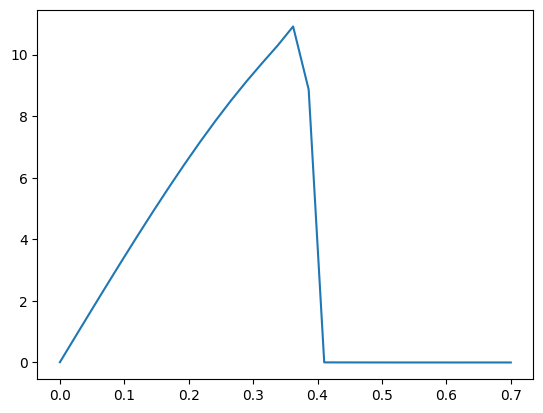

100%|██████████| 99/99 [12:48<00:00,  7.76s/it]


{'q_scan_gaps': Array([[1.5580587 , 1.5575342 , 1.5559669 , 1.5533346 , 1.5496317 ,
         1.5448275 , 1.5389013 , 1.5318131 , 1.5235105 , 1.5139184 ,
         1.502949  , 1.4906869 , 1.4770191 , 1.4621413 , 1.446887  ,
         1.4339949 , 1.2944114 , 0.00303804, 0.00392914, 0.00459333,
         0.00498569, 0.00509107, 0.00493761, 0.00459173, 0.00415657,
         0.00365593, 0.00316787, 0.00272169, 0.00232919, 0.00199185]],      dtype=float32),
 'q_scan_currents': Array([[ 0.0000000e+00,  8.3479273e-01,  1.6667553e+00,  2.4928136e+00,
          3.3100884e+00,  4.1153870e+00,  4.9056644e+00,  5.6775165e+00,
          6.4273415e+00,  7.1511025e+00,  7.8442998e+00,  8.5055437e+00,
          9.1305504e+00,  9.7210426e+00,  1.0294563e+01,  1.0916245e+01,
          8.8665323e+00, -5.5123055e-03, -6.4984928e-03, -7.1913511e-03,
         -7.6718996e-03, -8.0052149e-03, -8.2354173e-03, -8.3897458e-03,
         -8.5051432e-03, -8.5485345e-03, -8.5495897e-03, -8.5165948e-03,
         -8.456449

In [13]:
run_full_scan(temp = 0.45, phonon_scattering = 0.1, eta = 0.05)


## Load and plot

In [4]:
def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data


In [5]:
def save_data(data, filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data, output)
        
def load_data(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data


def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

    return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]


In [8]:
import numpy as np
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

eta_list = [0.05]
eta_list = [0.05]
temp_list = [0.45]
phonon_scattering_list = [0.1]
labels = []
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + '.pkl'
            data_theory_dictionaries += [load_file(filename)]
            labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(99, 4)
dict_keys(['q_scan_gaps', 'q_scan_currents', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


/tmp/ipykernel_8419/516486049.py:8: RuntimeWarning: invalid value encountered in divide
  axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)


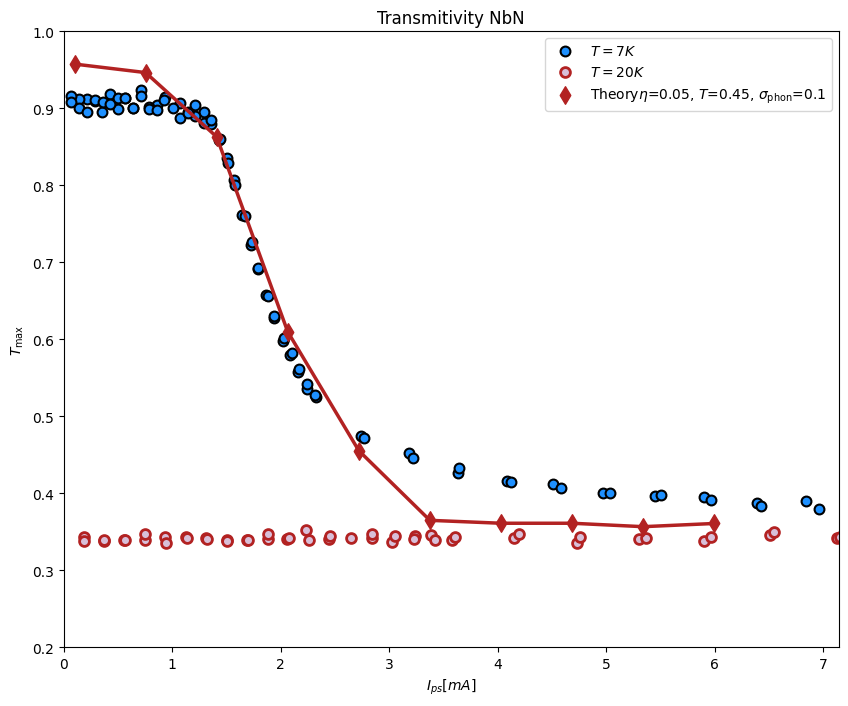

In [9]:

I_c = 35
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c/sc_data_y, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = 0
crt_dict = data_theory_dictionaries[index ]
axs.scatter(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)


plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

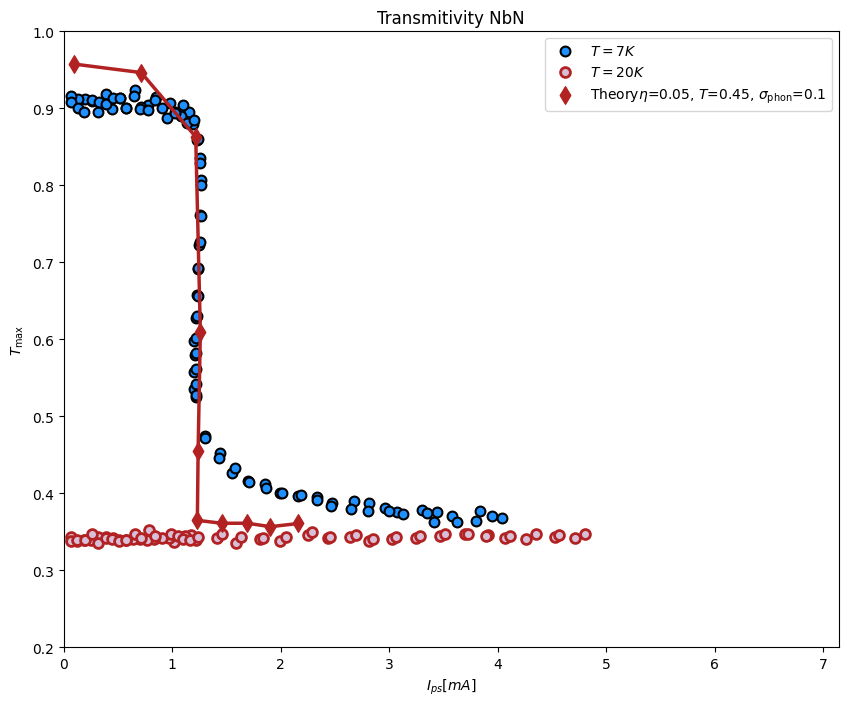

In [10]:


I_c = 35
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,170/I_c)


index = 0
crt_dict = data_theory_dictionaries[index ]
axs.scatter(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1) * jnp.array(crt_dict['transmitivity']),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1) * jnp.array(crt_dict['transmitivity']),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)

plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')


In [11]:
import numpy as np
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

eta_list = [0.05]
eta_list = [0.05]
temp_list = [0.45]
phonon_scattering_list = [0.1]
labels = []
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + '.pkl'
            data_theory_dictionaries += [load_file(filename)]
            labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(99, 4)
dict_keys(['q_scan_gaps', 'q_scan_currents', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


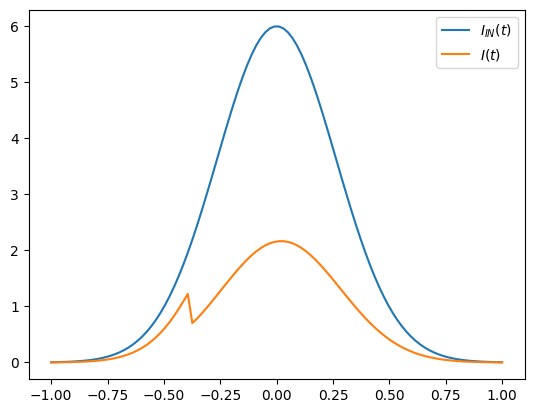

In [27]:
times = data_theory_dictionaries[0]['times']
data_x = data_theory_dictionaries[0]['pulse_in']
data_y = data_theory_dictionaries[0]['current_vs_time']

plt.plot(times[-1], data_x[-1], label = r'$I_{IN}(t)$')
plt.plot(times[-1], data_y[-1], label = r'$I(t)$')
plt.legend()

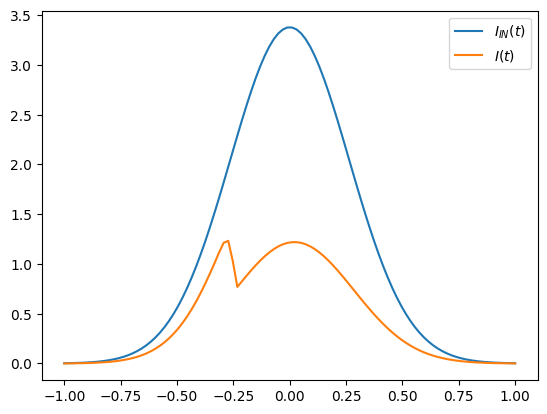

In [ ]:
times = data_theory_dictionaries[0]['times']
data_x = data_theory_dictionaries[0]['pulse_in']
data_y = data_theory_dictionaries[0]['current_vs_time']

plt.plot(times[5], data_x[5], label = r'$I_{IN}(t)$')
plt.plot(times[5], data_y[5], label = r'$I(t)$')
plt.legend()
